In [428]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import statsmodels.api as sm

from functools import reduce
from sklearn.preprocessing import MinMaxScaler

In [327]:
warnings.filterwarnings("ignore", category=UserWarning)
# 한글 폰트 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스(-) 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

## [Step 1. 기회의 발견] : "구조적 변화의 시그널, 그리고 3개월의 골든타임"

- 목적: 단순한 유행이 아닌 '구조적 소비 변화'를 증명하고, 지금 당장 움직여야 하는 '시급성(Urgency)'을 어필

- 논리:
    - 데이터랩의 타겟 키워드(예: 배달비, OTT 요금) 검색량 스파이크와 함께 소비 트렌드를 확인할 수 있는 지표를 교차 검증하여, 이것이 일시적 불만이 아닌 구조적으로 고착화된 메가 트렌드임을 증명
    - 데이터를 보고 '신규 카드'를 출시하려면 최소 6개월이 걸림 \
      우리는 그들이 준비하는 동안, 즉 앞으로의 3~4개월을 시장을 선점할 수 있는 '골든타임'으로 정의

### 1. 데이터 전처리

In [328]:
cols = ['날짜', '검색량 지수']

In [329]:
# 해외여행 거시환경/페인 포인트 키워드 검색량
travel = pd.read_excel('data/travel_monthly.xlsx', header=6, names=cols)
travel['날짜'] = pd.to_datetime(travel['날짜'])
travel_pain = pd.read_excel('data/travel_pain_monthly.xlsx', header=6, names=cols)
travel_pain['날짜'] = pd.to_datetime(travel_pain['날짜'])

# 배달 거시환경/페인 포인트 키워드 검색량
delivery = pd.read_excel('data/delivery_monthly.xlsx', header=6, names=cols)
delivery['날짜'] = pd.to_datetime(delivery['날짜'])
delivery_pain = pd.read_excel('data/delivery_pain_monthly.xlsx', header=6, names=cols)
delivery_pain['날짜'] = pd.to_datetime(delivery_pain['날짜'])

In [330]:
# 국민 해외관광객 추이
traveler = pd.read_csv('data/국민_해외관광객_추이(201601-202603).csv')
trav_tr = traveler[
    traveler['성별'].isin(['전체', '승무원'])
    ].pivot(
        index='기준일자', columns='성별', values='인원'
    ).assign(
        인원=lambda x: x['전체'] - x['승무원']
    )[['인원']].reset_index().iloc[:-1]
trav_tr.rename(columns={'기준일자':'날짜'}, inplace=True)
trav_tr['날짜'] = pd.to_datetime(trav_tr['날짜'], format='%Y%m')
trav_tr.columns.name = None

In [331]:
# 배달 소비 추이 (인터넷, 모바일 합산)
deliv_tr = pd.read_excel(
    'data/온라인쇼핑몰_판매매체별_음식서비스거래액(201701-202601).xlsx',
    header=1,
    usecols=['시점', '계'],
    dtype={'시점': str}
)
deliv_tr.rename(columns={'시점':'날짜', '계':'총거래액'}, inplace=True)
deliv_tr['날짜'] = pd.to_datetime(deliv_tr['날짜'], format='%Y.%m')

##### 데이터 병합

In [332]:
dfs = [travel, travel_pain, trav_tr, delivery, delivery_pain, deliv_tr]

start = max(df['날짜'].min() for df in dfs)
end = min(df['날짜'].max() for df in dfs)

print(start)
print(end)

# 가장 짧은 기간으로 통일
dfs = [
    df[(df['날짜'] >= start) & (df['날짜'] <= end)]
    for df in dfs
]

2017-01-01 00:00:00
2026-01-01 00:00:00


In [333]:
# 해외여행 관련 지표 합치기
travel_df = reduce(
    lambda left, right:
    pd.merge(left, right, on='날짜', how='inner'),
    dfs[:3]
)

# 배달 관련 지표 합치기
deliver_df = reduce(
    lambda left, right:
    pd.merge(left, right, on='날짜', how='inner'),
    dfs[3:6]
)

In [334]:
travel_df = travel_df.rename(columns={
    '검색량 지수_x': '해외여행_검색량',
    '검색량 지수_y': '환전_검색량'
})

deliver_df = deliver_df.rename(columns={
    '검색량 지수_x': '배달_검색량',
    '검색량 지수_y': '배달비_검색량'
})

##### 파생 변수(불만 지수) 생성

In [335]:
# '진성 불만 지수' = (페인 포인트 검색량 / 거시환경 검색량) * 100
# travel_df['진성_불만_지수'] = (
#     travel_df['환전_검색량'] / travel_df['해외여행_검색량']
# ) * 100

deliver_df['진성_불만_지수'] = (
    deliver_df['배달비_검색량'] / deliver_df['배달_검색량']
) * 100

In [337]:
# travel_df.to_csv('data/travel_data.csv', index=False, encoding='utf-8-sig')

In [336]:
travel_df.head()

,날짜,해외여행_검색량,환전_검색량,인원
0,2017-01-01,66.50657,75.12730,2202130.0
1,2017-02-01,54.87430,73.74182,2104667.0
2,2017-03-01,49.09206,61.88529,1806995.0
3,2017-04-01,43.20492,55.29269,1874426.0
4,2017-05-01,49.23792,59.41378,1869653.0


In [316]:
print(travel_df.shape)
print(travel_df.info())

(109, 4)
<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        109 non-null    datetime64[us]
 1   해외여행_검색량  109 non-null    float64       
 2   환전_검색량    109 non-null    float64       
 3   인원        109 non-null    float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 3.5 KB
None


In [317]:
deliver_df.head()

,날짜,배달_검색량,배달비_검색량,총거래액,진성_불만_지수
0,2017-01-01,35.80785,0.51492,183355,1.438009
1,2017-02-01,31.61120,0.64366,173924,2.036177
2,2017-03-01,31.86513,0.53977,192095,1.693921
3,2017-04-01,30.34372,0.57364,196543,1.890474
4,2017-05-01,30.77623,0.60074,210565,1.951961


In [318]:
print(deliver_df.shape)
print(deliver_df.info())

(109, 5)
<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        109 non-null    datetime64[us]
 1   배달_검색량    109 non-null    float64       
 2   배달비_검색량   109 non-null    float64       
 3   총거래액      109 non-null    int64         
 4   진성_불만_지수  109 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 4.4 KB
None


### 2. 스케일링 및 변곡점 도출(시각화)

In [338]:
# # 스케일러 생성
# scaler = MinMaxScaler()

#### 해외여행

##### 스케일링

In [339]:
# # 날짜 제외한 수치형 컬럼 선택
# cols = ['해외여행_검색량', '환전_검색량', '인원']
# # 원본 복사
# travel_scaling_df = travel_df.copy()
# # 스케일링 적용
# travel_scaling_df[cols] = scaler.fit_transform(travel_scaling_df[cols])
# # 확인
# travel_scaling_df.head()

,날짜,해외여행_검색량,환전_검색량,인원
0,2017-01-01,0.641469,0.687470,0.708615
1,2017-02-01,0.516951,0.670061,0.677170
2,2017-03-01,0.455054,0.521082,0.581128
3,2017-04-01,0.392035,0.438245,0.602884
4,2017-05-01,0.456616,0.490027,0.601344


In [340]:
# travel_scaling_df.to_csv('data/travel_scaling_data.csv', index=False, encoding='utf-8-sig')

##### 시각화

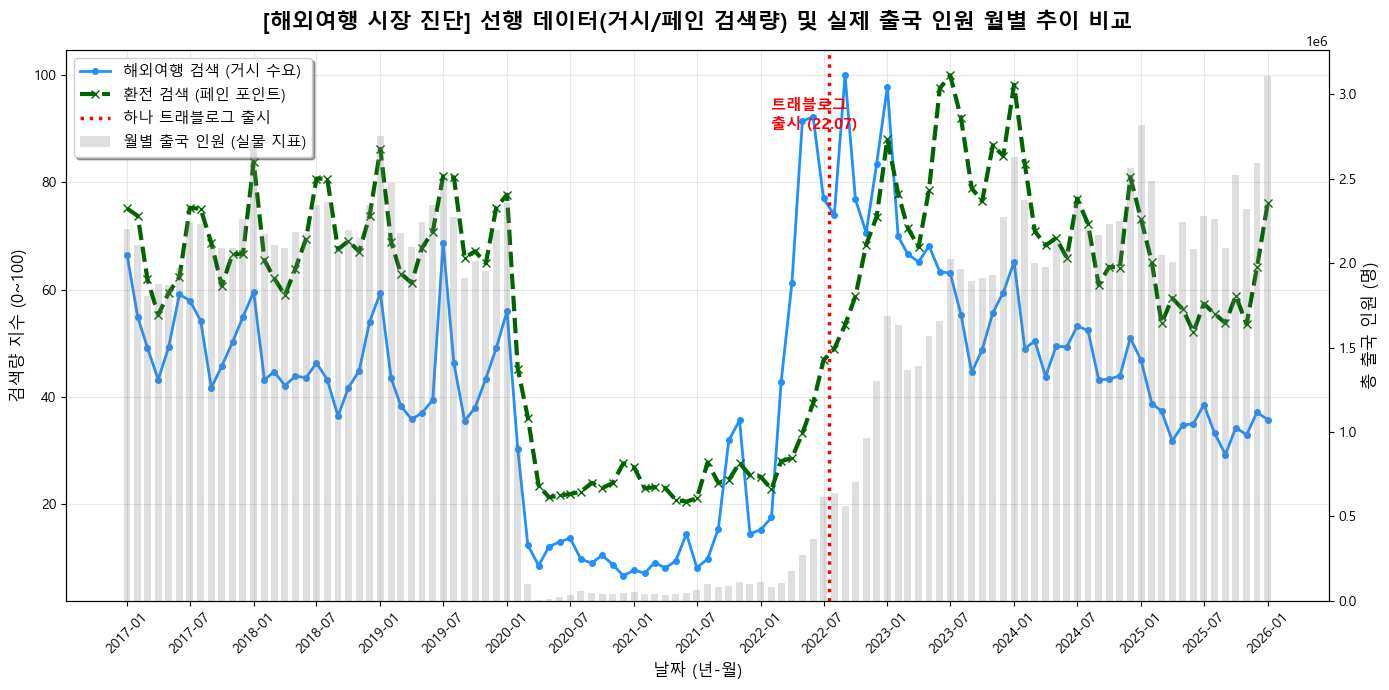

In [400]:
# ============================
# 월별 추이 비교
# ============================
fig, ax1 = plt.subplots(figsize=(14, 7))

# ==========================================
# 1. 보조 축(ax2): 월별 출국 인원 (막대 그래프)
# ==========================================
ax2 = ax1.twinx()
ax2.bar(travel_df['날짜'], travel_df['인원'], width=20, alpha=0.25, color='gray', label='월별 출국 인원 (실물 지표)')
ax2.set_ylabel('총 출국 인원 (명)', fontsize=12)

# ==========================================
# 2. 주 축(ax1): 검색량 트렌드 (선 그래프)
# ==========================================
ax1.plot(travel_df['날짜'], travel_df['해외여행_검색량'], label='해외여행 검색 (거시 수요)', color='dodgerblue', linewidth=2, marker='o', markersize=4)
ax1.plot(travel_df['날짜'], travel_df['환전_검색량'], label='환전 검색 (페인 포인트)', color='darkgreen', linewidth=3, linestyle='--', marker='x')

# 하나 트래블로그 출시 수직선 & 텍스트 추가 (2022년 7월)
ax1.axvline(pd.to_datetime('2022-07-18'), color='red', linestyle=':', linewidth=2.5, label='하나 트래블로그 출시')
# 텍스트 위치는 환전 검색량 최대치의 90% 높이쯤에 배치하여 겹치지 않게 설정
ax1.text(pd.to_datetime('2022-02-01'), travel_df['환전_검색량'].max() * 0.9, '트래블로그\n출시 (22.07)', color='red', fontsize=11, fontweight='bold')

# ==========================================
# 3. 차트 디자인 및 포맷팅
# ==========================================
ax1.set_xlabel('날짜 (년-월)', fontsize=12)
ax1.set_ylabel('검색량 지수 (0~100)', fontsize=12)
plt.title('[해외여행 시장 진단] 선행 데이터(거시/페인 검색량) 및 실제 출국 인원 월별 추이 비교', fontsize=16, fontweight='bold', pad=15)

# X축 눈금 설정 (6개월 단위)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.get_xticklabels(), rotation=45)

# 주 축과 보조 축의 범례(Legend) 하나로 통합
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, frameon=True, shadow=True)

# 그리드 및 레이아웃 정리
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 배달

##### 스케일링

In [303]:
# 날짜 제외한 수치형 컬럼 선택
cols = ['배달_검색량', '배달비_검색량', '총거래액']
# 원본 복사
deliver_scaling_df = deliver_df.copy()
# 스케일링 적용
deliver_scaling_df[cols] = scaler.fit_transform(deliver_scaling_df[cols])
# 확인
deliver_scaling_df.head()

,날짜,배달_검색량,배달비_검색량,총거래액,진성_불만_지수
0,2017-01-01,0.268408,0.000000,0.002581,1.438009
1,2017-02-01,0.220579,0.001294,0.000000,2.036177
2,2017-03-01,0.223473,0.000250,0.004973,1.693921
3,2017-04-01,0.206133,0.000590,0.006190,1.890474
4,2017-05-01,0.211063,0.000863,0.010027,1.951961


##### 시각화

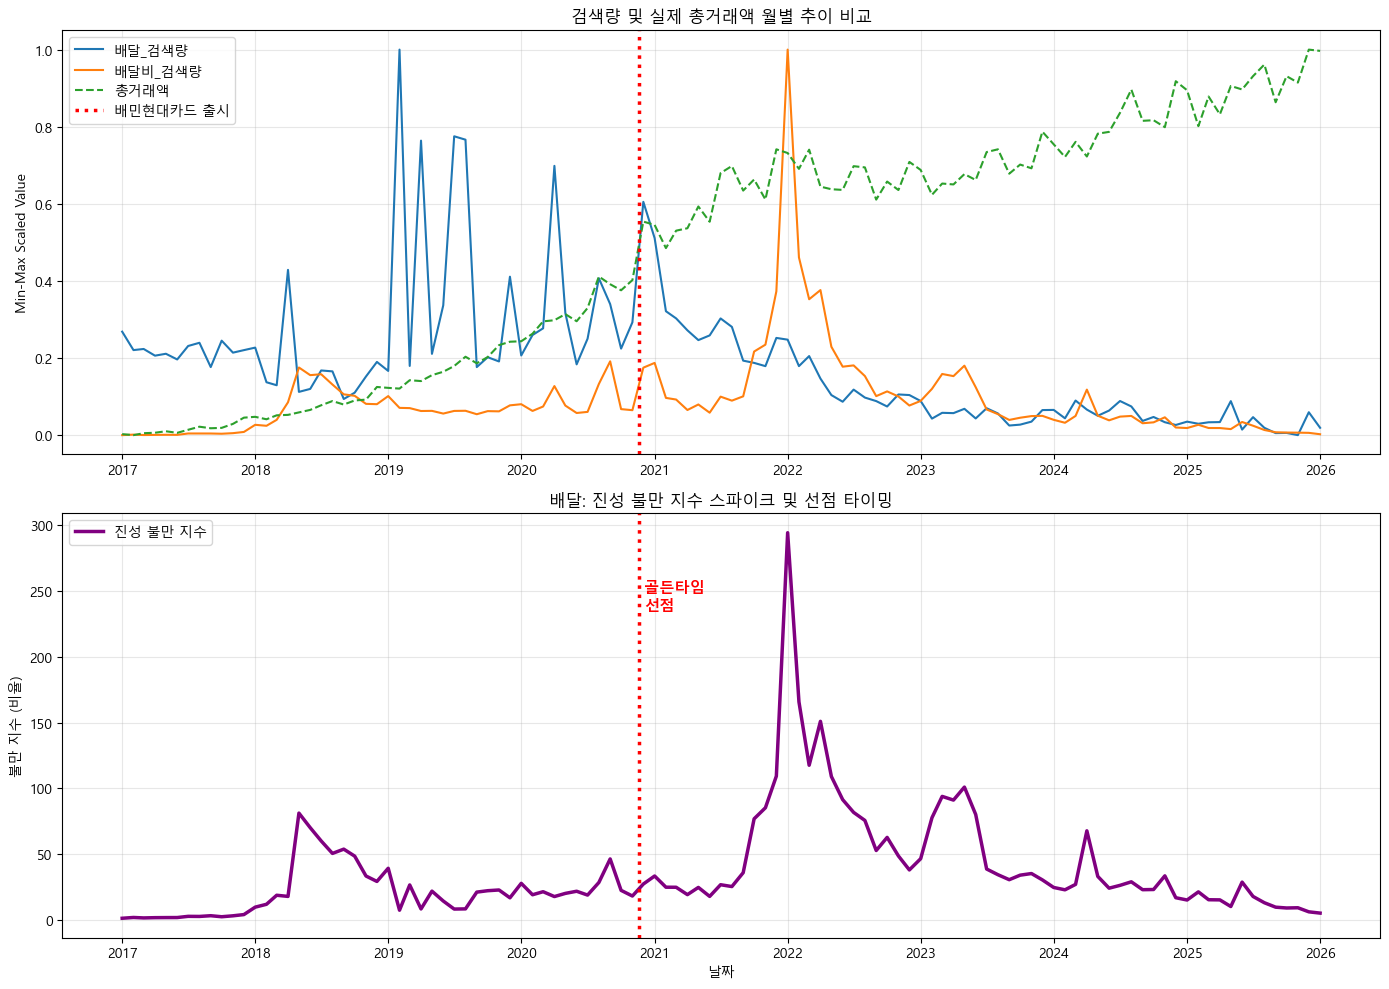

In [263]:
plt.figure(figsize=(14, 10))
# ============================
# 월별 추이 비교
# ============================
plt.subplot(2, 1, 1)
for col in ['배달_검색량', '배달비_검색량', '총거래액']:
    if col != '총거래액':
        plt.plot(deliver_scaling_df['날짜'], deliver_scaling_df[col], label=col)
    else:
        plt.plot(deliver_scaling_df['날짜'], deliver_scaling_df[col], label=col, linestyle='--')

# 배민현대카드 출시 수직선 추가 (2020년 11월)
plt.axvline(pd.to_datetime('2020-11-19'), color='red', linestyle=':', linewidth=2.5, label='배민현대카드 출시')

plt.ylabel('Min-Max Scaled Value')
plt.title('검색량 및 실제 총거래액 월별 추이 비교')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# ============================
# 진성 불만 지수
# ============================
plt.subplot(2, 1, 2)

plt.plot(deliver_scaling_df['날짜'], deliver_scaling_df['진성_불만_지수'], label='진성 불만 지수', color='purple', linewidth=2.5)

# 하단 차트에도 동일하게 수직선 추가
plt.axvline(pd.to_datetime('2020-11-19'), color='red', linestyle=':', linewidth=2.5)
plt.text(pd.to_datetime('2020-12-04'), 
         deliver_scaling_df['진성_불만_지수'].max() * 0.8, 
         '골든타임\n선점', color='red', fontsize=11, fontweight='bold')

plt.xlabel('날짜')
plt.ylabel('불만 지수 (비율)')
plt.title('배달: 진성 불만 지수 스파이크 및 선점 타이밍')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 시각화

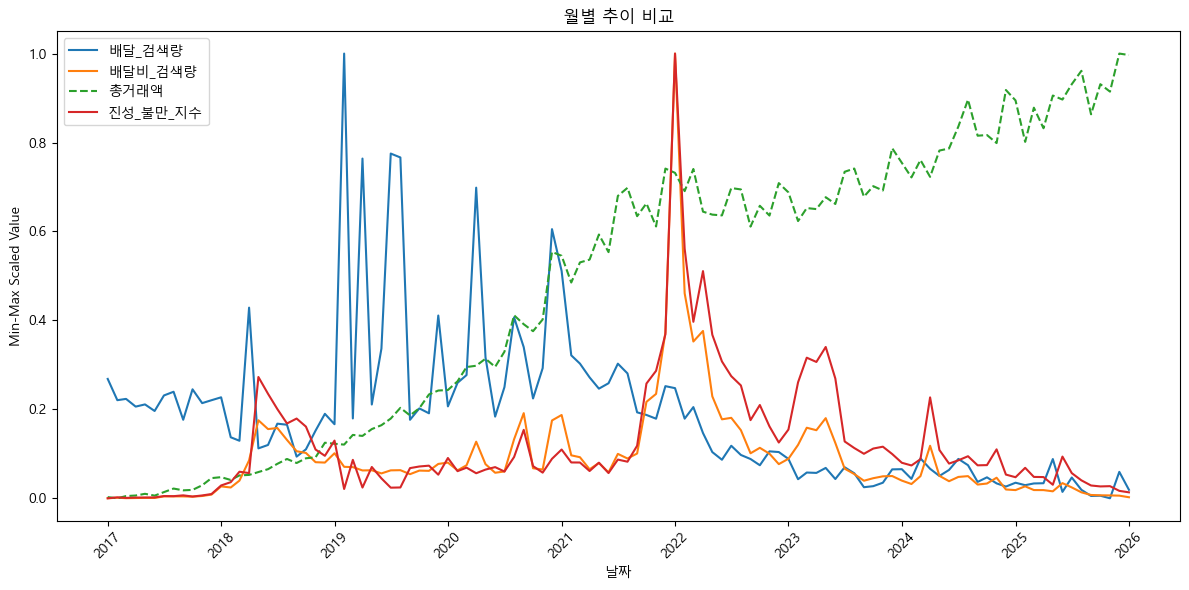

In [237]:
plt.figure(figsize=(12,6))

for col in ['배달_검색량', '배달비_검색량', '총거래액']:
    if col != '총거래액':
        plt.plot(deliver_scaling_df['날짜'], deliver_scaling_df[col], label=col)
    else:
        plt.plot(deliver_scaling_df['날짜'], deliver_scaling_df[col], label=col, linestyle='--')

plt.xlabel('날짜')
plt.ylabel('Min-Max Scaled Value')
plt.title('월별 추이 비교')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

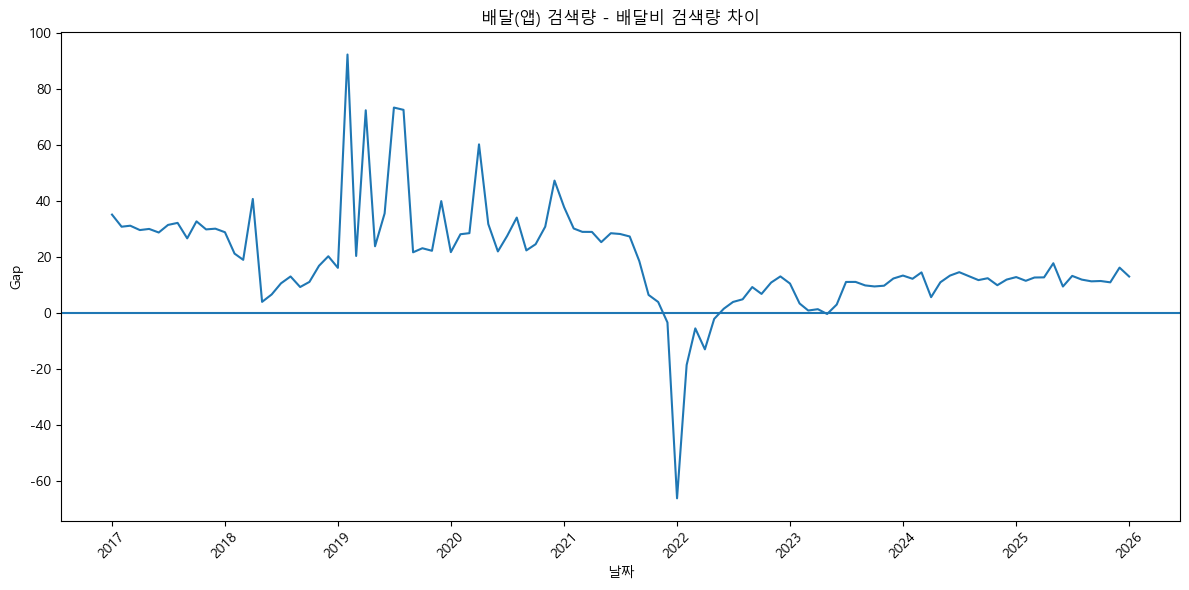

In [227]:
deliver_df['검색_차이'] = deliver_df['배달_검색량'] - deliver_df['배달비_검색량']

plt.figure(figsize=(12,6))

plt.plot(
    deliver_df['날짜'],
    deliver_df['검색_차이']
)

plt.axhline(y=0)

plt.xlabel('날짜')
plt.ylabel('Gap')
plt.title('배달(앱) 검색량 - 배달비 검색량 차이')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 3. 교차 상관분석(CCF) 진행

#### 해외여행

In [229]:
# ---------------------------------------------------------
# 정상성 확보: 차분(Differencing) 적용
# ---------------------------------------------------------
# 시계열 데이터의 우상향 추세(Trend)를 제거하여 순수한 '변동량'만 남기기 위한 필수 작업입니다.
df_diff = travel_df[['진성_불만_지수', '인원']].diff()
df_diff = df_diff.replace([np.inf, -np.inf], np.nan).dropna()

# 핵심: statsmodels의 인덱스 충돌 에러를 막기 위해 .values를 붙여 '순수 Numpy 배열'로 변환합니다.
diff_complaint = df_diff['진성_불만_지수'].values
diff_payment = df_diff['인원'].values
print(f"불만 지수 길이: {len(diff_complaint)}, 인원 길이: {len(diff_payment)}")
print(f"Inf 존재 여부: {np.isinf(diff_complaint).any()}") # False가 나와야 정상

불만 지수 길이: 108, 인원 길이: 108
Inf 존재 여부: False


In [230]:
# ---------------------------------------------------------
# 교차 상관분석 (Cross-Correlation Function, CCF)
# ---------------------------------------------------------
# statsmodels 라이브러리를 활용하여 CCF 계산
# adjusted=False: 대규모 시계열 데이터에 주로 쓰이는 일반적 추정 방식
ccf_values = sm.tsa.stattools.ccf(diff_complaint, diff_payment, adjusted=False)

# 최대 12개월(1년)까지의 시차(Lag)만 추출하여 확인
max_lag = 12
ccf_values_subset = ccf_values[:max_lag]
lags = np.arange(max_lag)

# 결과 수치 출력
print("■ 개월 수(Lag)에 따른 교차 상관계수:")
for lag, coef in zip(lags, ccf_values_subset):
    print(f"Lag {lag}개월: {coef:.4f}")

■ 개월 수(Lag)에 따른 교차 상관계수:
Lag 0개월: -0.1024
Lag 1개월: -0.1105
Lag 2개월: 0.1403
Lag 3개월: 0.2122
Lag 4개월: 0.0048
Lag 5개월: -0.0972
Lag 6개월: -0.2127
Lag 7개월: 0.0291
Lag 8개월: 0.1372
Lag 9개월: -0.1269
Lag 10개월: -0.1720
Lag 11개월: 0.0662


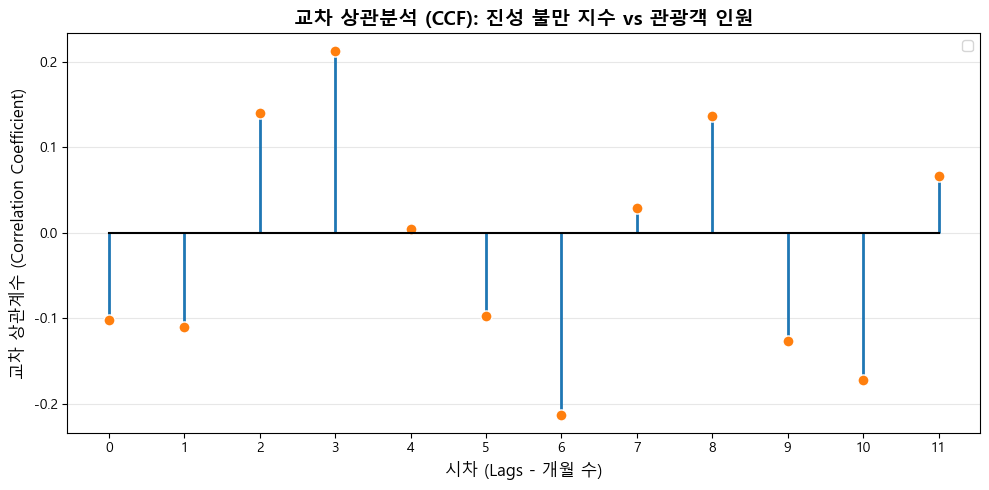

In [232]:
# ---------------------------------------------------------
# 시각화 (Stem Plot)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))

# Stem 차트로 각 개월 수(Lag)마다의 상관계수를 막대 형태로 시각화
markerline, stemlines, baseline = plt.stem(lags, ccf_values_subset, basefmt="k-")

# 시각적 가시성을 위한 디자인 처리
plt.setp(stemlines, 'linewidth', 2, 'color', '#1f77b4')
plt.setp(markerline, 'markersize', 8, 'markerfacecolor', '#ff7f0e', 'markeredgecolor', 'w')

plt.title('교차 상관분석 (CCF): 진성 불만 지수 vs 관광객 인원', fontsize=14, fontweight='bold')
plt.xlabel('시차 (Lags - 개월 수)', fontsize=12)
plt.ylabel('교차 상관계수 (Correlation Coefficient)', fontsize=12)

# 상관성이 가장 강한 지점(Lag 3)을 강조하는 수평선 (선택사항)
# plt.axhline(y=-0.18, color='red', linestyle='--', alpha=0.5, label='골든타임 시그널 (음의 상관 극대화)')

plt.grid(True, axis='y', alpha=0.3)
plt.xticks(lags)
plt.legend()
plt.tight_layout()

plt.show()

#### 배달

In [233]:
# ---------------------------------------------------------
# 정상성 확보: 차분(Differencing) 적용
# ---------------------------------------------------------
# 시계열 데이터의 우상향 추세(Trend)를 제거하여 순수한 '변동량'만 남기기 위한 필수 작업입니다.
df_diff = deliver_df[['진성_불만_지수', '총거래액']].diff()
df_diff = df_diff.replace([np.inf, -np.inf], np.nan).dropna()

# 핵심: statsmodels의 인덱스 충돌 에러를 막기 위해 .values를 붙여 '순수 Numpy 배열'로 변환합니다.
diff_complaint = df_diff['진성_불만_지수'].values
diff_payment = df_diff['총거래액'].values
print(f"불만 지수 길이: {len(diff_complaint)}, 인원 길이: {len(diff_payment)}")
print(f"Inf 존재 여부: {np.isinf(diff_complaint).any()}") # False가 나와야 정상

불만 지수 길이: 108, 인원 길이: 108
Inf 존재 여부: False


In [234]:
# ---------------------------------------------------------
# 교차 상관분석 (Cross-Correlation Function, CCF)
# ---------------------------------------------------------
# statsmodels 라이브러리를 활용하여 CCF 계산
# adjusted=False: 대규모 시계열 데이터에 주로 쓰이는 일반적 추정 방식
ccf_values = sm.tsa.stattools.ccf(diff_complaint, diff_payment, adjusted=False)

# 최대 12개월(1년)까지의 시차(Lag)만 추출하여 확인
max_lag = 12
ccf_values_subset = ccf_values[:max_lag]
lags = np.arange(max_lag)

# 결과 수치 출력
print("■ 개월 수(Lag)에 따른 교차 상관계수:")
for lag, coef in zip(lags, ccf_values_subset):
    print(f"Lag {lag}개월: {coef:.4f}")

■ 개월 수(Lag)에 따른 교차 상관계수:
Lag 0개월: -0.0309
Lag 1개월: 0.2482
Lag 2개월: -0.2446
Lag 3개월: 0.1031
Lag 4개월: -0.0413
Lag 5개월: 0.0763
Lag 6개월: 0.1873
Lag 7개월: -0.2153
Lag 8개월: 0.0908
Lag 9개월: -0.0142
Lag 10개월: 0.0617
Lag 11개월: -0.1218


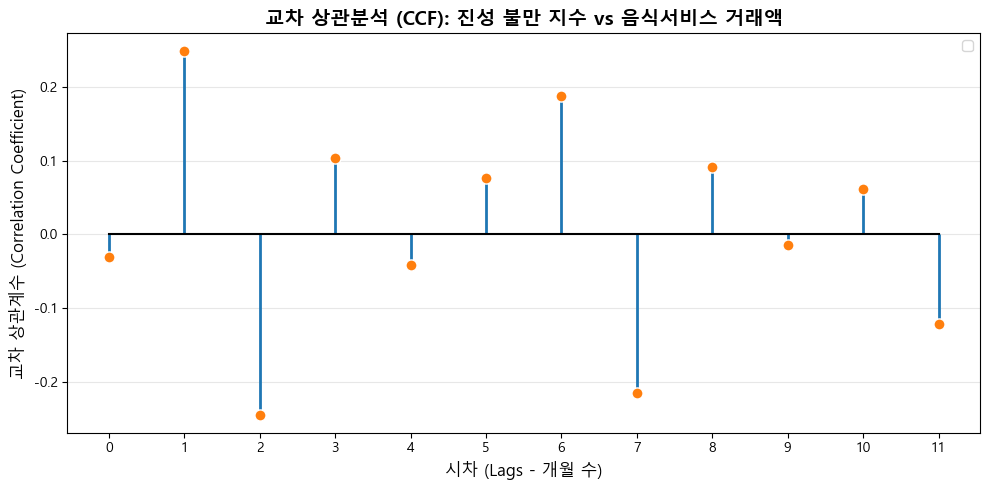

In [236]:
# ---------------------------------------------------------
# 시각화 (Stem Plot)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))

# Stem 차트로 각 개월 수(Lag)마다의 상관계수를 막대 형태로 시각화
markerline, stemlines, baseline = plt.stem(lags, ccf_values_subset, basefmt="k-")

# 시각적 가시성을 위한 디자인 처리
plt.setp(stemlines, 'linewidth', 2, 'color', '#1f77b4')
plt.setp(markerline, 'markersize', 8, 'markerfacecolor', '#ff7f0e', 'markeredgecolor', 'w')

plt.title('교차 상관분석 (CCF): 진성 불만 지수 vs 음식서비스 거래액', fontsize=14, fontweight='bold')
plt.xlabel('시차 (Lags - 개월 수)', fontsize=12)
plt.ylabel('교차 상관계수 (Correlation Coefficient)', fontsize=12)

# 상관성이 가장 강한 지점(Lag 3)을 강조하는 수평선 (선택사항)
# plt.axhline(y=-0.18, color='red', linestyle='--', alpha=0.5, label='골든타임 시그널 (음의 상관 극대화)')

plt.grid(True, axis='y', alpha=0.3)
plt.xticks(lags)
plt.legend()
plt.tight_layout()

plt.show()

## [Step 2. 시장 진단] : "혜택의 허상: 고객의 니즈와 카드사 룰(Rule)의 엇박자"

- 목적: 기존 카드들이 고객의 진짜 페인 포인트를 해결하지 못하는 이유를 '카드사의 수익 방어 장치' 관점에서 날카롭게 파헤치기

- 논리:
    - 수집한 2,800여 개의 카드 데이터를 분석하여 겉보기 혜택이 아닌 '전월 실적'과 '통합 할인 한도'를 기준으로 군집화(Clustering) \
      (통합 할인 한도 없는데 어쩌지)
    - "배달비 할인을 내세우는 카드는 많지만, 전월 실적 허들이 낮으면서도 실질적인 할인 체감률(한도)이 높은 카드는 시장에 00%도 안 된다"는 것을 대시보드로 시각화하여 진짜 빈집을 찾아냄

이거는 기존에 세웠던 6개월 키워드 탐색 - 부족한 상품 추출로 해야되는 거 아니려나?
- 최근 트렌드를 키워드 검색량으로 탐색
- 현재 발급 가능한(단종 X) 카드들 중, 해당 혜택을 제공하는 카드들이 있는지 확인 및 연회비, 전월실적 등 파악
    - 이때, 단종된 카드들도 파악해서 이미 기존에 시도했다 실패한 키워드인지 확인 과정이 필요할 듯 (진짜 블루오션인지)
    - 데이터프레임 카테고리를 최대한 묶는 작업도 여기서 필요
    - 아니면 카드사별로 어떤 혜택에 집중했는지, 이런 것도 같이 봐야할까?



### 카드 데이터

In [532]:
df = pd.read_csv('data/card_data.csv', index_col=0)
df.head()

,카드명,카드사,카드타입,출시일,연회비,전월실적,카테고리,주요혜택,발급가능여부
카드번호,,,,,,,,,
1,신한카드 Hi-Point,신한카드,CRD,NaN,8000,0,"쇼핑, 모든가맹점, 주유, 금융, 통신, 적립","전국가맹점 0.2~2.0% 적립, 특정가맹점 1~5% 적립, 에이치디현대오일뱅크 6...",X
2,신한카드 Love,신한카드,CRD,NaN,8000,200000,"백화점, 패밀리레스토랑, 주유소, 영화, 적립, 테마파크, 경기관람","백화점/할인점 5% 할인, 스타벅스 20% 할인, GS칼텍스 60원/L 할인",X
3,신한카드 Lady,신한카드,CRD,NaN,5000,300000,"쇼핑, 푸드, 영화, 주유소, 교육/육아, 테마파크, 통신, 경기관람","3대백화점 5% 할인, 패밀리레스토랑 20% 할인, 놀이공원 30~50% 할인",X
4,SK에너지 신한카드The you,신한카드,CRD,NaN,7000,300000,"주유소, 대중교통, 무이자할부, 테마파크, 영화, 헤어, 경기관람, 여행사","SK주유소 100원/L 할인, 지하철,버스,택시 3~7% 할인, 놀이공원 30~50...",X
8,신한카드 The CLASSIC-Y,신한카드,CRD,NaN,100000,0,"선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄","Gift Option 매년1회 선택이용, 마이신한포인트 0.7~5% 적립, GS칼텍...",O


In [533]:
df.shape

(2502, 9)

In [534]:
df.info()

<class 'pandas.DataFrame'>
Index: 2502 entries, 1 to 2985
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   카드명     2502 non-null   str  
 1   카드사     2502 non-null   str  
 2   카드타입    2502 non-null   str  
 3   출시일     300 non-null    str  
 4   연회비     2502 non-null   int64
 5   전월실적    2502 non-null   int64
 6   카테고리    2477 non-null   str  
 7   주요혜택    2498 non-null   str  
 8   발급가능여부  2502 non-null   str  
dtypes: int64(2), str(7)
memory usage: 195.5 KB


In [535]:
df.isnull().sum()

카드명          0
카드사          0
카드타입         0
출시일       2202
연회비          0
전월실적         0
카테고리        25
주요혜택         4
발급가능여부       0
dtype: int64

In [536]:
df.dropna(subset=['카테고리', '주요혜택'], inplace=True)
df.isnull().sum()

카드명          0
카드사          0
카드타입         0
출시일       2178
연회비          0
전월실적         0
카테고리         0
주요혜택         0
발급가능여부       0
dtype: int64

#### 카테고리 분류

In [349]:
# # pd.set_option('display.max_rows', None)  # 모든 행 출력
# # pd.set_option('display.max_columns', None)  # 모든 열 출력
# # pd.set_option('display.max_colwidth', None)  # 열 내용 길이 제한 해제
# # pd.set_option('display.width', None)  # 출력 폭 제한 해제
# pd.reset_option('all')

In [516]:
# 리스트 형태로 변환
df['카테고리'] = df['카테고리'].astype(object)
df['카테고리'] = df.loc[:, '카테고리'].str.split(', ')

In [517]:
df.head()

,카드명,카드사,카드타입,출시일,연회비,전월실적,카테고리,주요혜택,발급가능여부
카드번호,,,,,,,,,
1,신한카드 Hi-Point,신한카드,CRD,NaN,8000,0,"[쇼핑, 모든가맹점, 주유, 금융, 통신, 적립]","전국가맹점 0.2~2.0% 적립, 특정가맹점 1~5% 적립, 에이치디현대오일뱅크 6...",X
2,신한카드 Love,신한카드,CRD,NaN,8000,200000,"[백화점, 패밀리레스토랑, 주유소, 영화, 적립, 테마파크, 경기관람]","백화점/할인점 5% 할인, 스타벅스 20% 할인, GS칼텍스 60원/L 할인",X
3,신한카드 Lady,신한카드,CRD,NaN,5000,300000,"[쇼핑, 푸드, 영화, 주유소, 교육/육아, 테마파크, 통신, 경기관람]","3대백화점 5% 할인, 패밀리레스토랑 20% 할인, 놀이공원 30~50% 할인",X
4,SK에너지 신한카드The you,신한카드,CRD,NaN,7000,300000,"[주유소, 대중교통, 무이자할부, 테마파크, 영화, 헤어, 경기관람, 여행사]","SK주유소 100원/L 할인, 지하철,버스,택시 3~7% 할인, 놀이공원 30~50...",X
8,신한카드 The CLASSIC-Y,신한카드,CRD,NaN,100000,0,"[선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄]","Gift Option 매년1회 선택이용, 마이신한포인트 0.7~5% 적립, GS칼텍...",O


In [519]:
category = df.loc[:, '카테고리'].explode()
print(category.unique())
print(category.value_counts())

<StringArray>
[    '선택형',   '모든가맹점',     '주유소',      '생활',     '면세점',     '진에어',   '공연/전시',
    '프리미엄',    '대중교통',      '택시',
 ...
     '학습지',        '',    '전통시장',     '아울렛',     'SSM',   '국내가맹점',   '아이스크림',
 '혜택 프로모션',    '고속버스',    '동물병원']
Length: 128, dtype: str
카테고리
적립        317
카페        264
영화        262
생활        240
테마파크      233
         ... 
아울렛         2
진에어         1
SPA브랜드      1
            1
아이스크림       1
Name: count, Length: 128, dtype: int64


In [537]:
category_df = df.loc[df.loc[:, '카드사'] != 'BC 바로카드']
category_df = category_df.loc[category_df.loc[:, '발급가능여부'] == 'O']

In [538]:
# 매핑 사전(Dictionary) 정의
# 소비 영역 대분류
category_mapping = {
    '쇼핑/유통': ['쇼핑', '온라인쇼핑', '대형마트', '백화점', '편의점', '마트/편의점', '소셜커머스', '홈쇼핑', '드럭스토어', '화장품', '아울렛', '전통시장', 'SPA브랜드', 'SSM'],
    '외식/푸드': ['푸드', '카페', '카페/디저트', '베이커리', '아이스크림', '패밀리레스토랑', '일반음식점', '패스트푸드', '점심', '저녁', '배달앱'],
    '여행/항공': ['해외', '해외이용', '해외직구', '여행/숙박', '공항라운지', '공항라운지/PP', 'PP', '더라운지', '대한항공', '아시아나항공', '제주항공', '진에어', '저가항공', '항공권', '항공마일리지', '면세점', '호텔', '리조트', '공항', '여행사', '온라인 여행사'],
    '교통/모빌리티': ['주유', '주유소', '충전소', '대중교통', '교통', '정비', '자동차', '자동차/하이패스', '하이패스', '렌터카', '차/중고차', '택시', '기차', '고속버스'],
    '여가/문화': ['테마파크', '영화', '경기관람', 'OTT/영화/문화', '디지털구독', '음원사이트', '공연/전시', '도서', '레저/스포츠', '골프', '게임'],
    '생활/고정비': ['생활', '통신', 'SKT', 'KT', 'LGU+', '공과금', '공과금/렌탈', '렌탈', '병원', '약국', '병원/약국', '동물병원', '애완동물', '교육/육아', '학원', '학습지', '어린이집', '보험', '보험사', '헤어', '뷰티/피트니스', '피트니스', '인테리어'],
    '페이/금융': ['간편결제', '카카오페이', '삼성페이', '네이버페이', 'APP', '금융', '은행사', '증권사', '카드사'],
    '광범위': ['모든가맹점', '국내외가맹점', '국내가맹점', '프리미엄 서비스', '프리미엄', '비즈니스', '선택형']
}

In [539]:
# 검색 속도 향상을 위한 역방향 매핑 (소분류 -> 대분류)
reverse_mapping = {}
for big_cat, small_cats in category_mapping.items():
    for small in small_cats:
        reverse_mapping[small] = big_cat

In [540]:
def parse_category(row_data):
    # 1. 입력값이 float 형태의 결측치(NaN)인 경우 방어
    if isinstance(row_data, float) and np.isnan(row_data):
        return None, None
    
    # 2. 리스트인지 문자열인지 판별하여 items 리스트 생성
    if isinstance(row_data, list):
        # 리스트 형태인 경우
        items = [str(x).strip() for x in row_data]
    elif isinstance(row_data, str):
        # 아직 쪼개지지 않은 문자열 형태인 경우
        items = [x.strip() for x in row_data.split(',')]
    else:
        # 그 외의 이상한 데이터는 무시
        return None, None
    
    # # 3. 혜택 유형 추출
    # benefits = [item for item in items if item in benefit_types]
    
    # 4. 소비 영역 추출 및 중복 제거
    sectors = list(set([reverse_mapping.get(item) for item in items if item in reverse_mapping]))
    
    return ', '.join(sectors)

##### test

In [541]:
# 3. 문자열 리스트 파싱 및 중복 없는 대분류 추출 함수
def extract_unique_main_categories(row_data):
    # 결측치 처리
    if pd.isna(row_data):
        return []
    
    # 텍스트로 된 리스트(예: "['쇼핑', '온라인쇼핑']")를 실제 파이썬 리스트로 안전하게 변환
    try:
        items = ast.literal_eval(row_data)
    except:
        # 혹시 리스트 형태가 아닌 일반 문자열일 경우 콤마로 분리
        items = [x.strip() for x in str(row_data).split(',')]
        
    if not isinstance(items, list):
        items = [items]
        
    # set()을 사용하여 동일 카드 내 대분류 중복 방지 (쇼핑, 백화점이 들어와도 쇼핑/유통 1개로 처리)
    sectors = set() 
    for item in items:
        item = str(item).strip()
        if item in reverse_mapping:
            sectors.add(reverse_mapping[item])
            
    # set을 다시 list로 변환하여 반환
    return list(sectors)

In [542]:
# 4. 고유한 소비 영역 대분류 '리스트'를 새로운 컬럼으로 생성
category_df['소비영역_대분류_리스트'] = category_df['카테고리'].apply(extract_unique_main_categories)
category_df = category_df[category_df['소비영역_대분류_리스트'].map(len) > 0].copy()

In [543]:
# 5. 핵심: 리스트를 각 행으로 쪼개기 (Explode)
# 한 카드에 ['쇼핑/유통', '외식/푸드']가 있었다면, 이제 행이 2개로 복사되며 완전히 분리됨
df_exploded = category_df.explode('소비영역_대분류_리스트')
# 기존 컬럼과 헷갈리지 않게 이름 변경
df_exploded = df_exploded.rename(columns={'소비영역_대분류_리스트': '태블로용_소비대분류'})

In [544]:
df_exploded.to_csv('data/card_tableau_exploded.csv', index=False, encoding='utf-8-sig')

In [545]:
# 결과 확인 출력
print("■ 쪼개기(Explode) 완료! 데이터 예시 (상위 5개행):")
print(df_exploded[['카드명', '카테고리', '태블로용_소비대분류']].head(5))

■ 쪼개기(Explode) 완료! 데이터 예시 (상위 5개행):
                     카드명                                        카테고리  \
카드번호                                                                   
8     신한카드 The CLASSIC-Y  선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄   
8     신한카드 The CLASSIC-Y  선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄   
8     신한카드 The CLASSIC-Y  선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄   
8     신한카드 The CLASSIC-Y  선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄   
8     신한카드 The CLASSIC-Y  선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄   

     태블로용_소비대분류  
카드번호             
8       교통/모빌리티  
8         여가/문화  
8         여행/항공  
8        생활/고정비  
8           광범위  


In [546]:
df_exploded.head()

,카드명,카드사,카드타입,출시일,연회비,전월실적,카테고리,주요혜택,발급가능여부,태블로용_소비대분류
카드번호,,,,,,,,,,
8,신한카드 The CLASSIC-Y,신한카드,CRD,NaN,100000,0,"선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄","Gift Option 매년1회 선택이용, 마이신한포인트 0.7~5% 적립, GS칼텍...",O,교통/모빌리티
8,신한카드 The CLASSIC-Y,신한카드,CRD,NaN,100000,0,"선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄","Gift Option 매년1회 선택이용, 마이신한포인트 0.7~5% 적립, GS칼텍...",O,여가/문화
8,신한카드 The CLASSIC-Y,신한카드,CRD,NaN,100000,0,"선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄","Gift Option 매년1회 선택이용, 마이신한포인트 0.7~5% 적립, GS칼텍...",O,여행/항공
8,신한카드 The CLASSIC-Y,신한카드,CRD,NaN,100000,0,"선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄","Gift Option 매년1회 선택이용, 마이신한포인트 0.7~5% 적립, GS칼텍...",O,생활/고정비
8,신한카드 The CLASSIC-Y,신한카드,CRD,NaN,100000,0,"선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄","Gift Option 매년1회 선택이용, 마이신한포인트 0.7~5% 적립, GS칼텍...",O,광범위


In [547]:
# 리스트 형태로 변환
df_exploded['태블로용_소비대분류'] = df_exploded['태블로용_소비대분류'].astype(object)
df_exploded['태블로용_소비대분류'] = df_exploded.loc[:, '태블로용_소비대분류'].str.split(', ')

big_cat = df_exploded.loc[:, '태블로용_소비대분류'].explode()
print(big_cat.unique())
print(big_cat.value_counts())

<StringArray>
['교통/모빌리티', '여가/문화', '여행/항공', '생활/고정비', '광범위', '쇼핑/유통', '외식/푸드', '페이/금융']
Length: 8, dtype: str
태블로용_소비대분류
생활/고정비     583
여가/문화      516
광범위        489
외식/푸드      480
쇼핑/유통      475
교통/모빌리티    466
여행/항공      353
페이/금융      217
Name: count, dtype: int64


In [300]:
# df_ex = df.explode('카테고리')
# print(len(df_ex))
# # df.head()
# df_ex['소비_영역_대분류'] = df_ex.apply(
#     lambda row: parse_category(row['카테고리']), axis=1, result_type='expand')
# # df_ex.head()
# # 1. 각 행의 리스트 안에서 '' (빈 문자열)만 쏙 골라내서 제거
# df_ex['소비_영역_대분류'] = df_ex['소비_영역_대분류'].apply(
#     lambda x: [i for i in x if i.strip() != ''] if isinstance(x, list) else x)

# # 2. 빈 문자열을 지웠더니 아예 텅 빈 리스트([])가 되어버린 '깡통 카드' 행들을 통째로 삭제 (Drop rows)
# df_ex = df_ex[df_ex['소비_영역_대분류'].map(len) > 0]

# # 3. 깨끗해진 데이터로 다시 explode 해서 확인
# big_cat_ex = df_ex.loc[:, '소비_영역_대분류'].explode()
# print("■ 노이즈 제거 완료 후 카테고리 분포:")
# print(big_cat_ex.value_counts())

# # df_ex.to_csv('data/card_data_cleaned_expand.csv', index=False, encoding='utf-8-sig')

---

In [520]:
# 파생 변수 생성 적용
df['소비_영역_대분류'] = df.apply(
    lambda row: parse_category(row['카테고리']), 
    axis=1, result_type='expand'
)

In [521]:
df.head()

,카드명,카드사,카드타입,출시일,연회비,전월실적,카테고리,주요혜택,발급가능여부,소비_영역_대분류
카드번호,,,,,,,,,,
8,신한카드 The CLASSIC-Y,신한카드,CRD,NaN,100000,0,"[선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄]","Gift Option 매년1회 선택이용, 마이신한포인트 0.7~5% 적립, GS칼텍...",O,"교통/모빌리티, 여가/문화, 여행/항공, 생활/고정비, 광범위"
10,신한카드 B.Big(삑),신한카드,CRD,NaN,10000,300000,"[대중교통, 택시, 백화점, 카페, 편의점, 통신, 영화, 캐시백]","대중교통 200~600원 할인, 택시 10% 할인, KTX 10% 할인",O,"쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화, 생활/고정비"
12,신한카드 Air Platinum#,신한카드,CRD,NaN,40000,0,"[항공마일리지, 생활, 프리미엄]","1,500원당 1마일 적립, 1,000원당 1마일 적립",O,"여행/항공, 광범위, 생활/고정비"
13,신한카드 Mr.Life,신한카드,CRD,2015-09-03,15000,300000,"[공과금, 편의점, 병원/약국, 생활, 온라인쇼핑, 택시, 푸드, 대형마트, 주유소]","공과금 10% 할인, 마트,편의점 10% 할인, 식음료 10% 할인",O,"쇼핑/유통, 생활/고정비, 교통/모빌리티, 외식/푸드"
14,신한카드 YOLO ⓘ,신한카드,CRD,NaN,15000,300000,"[선택형, 카페, 편의점, 소셜커머스, 택시, 베이커리, 영화]","6개가맹점 할인율 선택, 스타벅스 쿠폰 제공",O,"쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화, 광범위"


In [522]:
# df.to_csv('data/card_data_cleaned.csv', index=True, encoding='utf-8-sig')
df[['카드명', '카테고리', '소비_영역_대분류']].head()

,카드명,카테고리,소비_영역_대분류
카드번호,,,
8,신한카드 The CLASSIC-Y,"[선택형, 모든가맹점, 주유소, 생활, 면세점, 진에어, 공연/전시, 프리미엄]","교통/모빌리티, 여가/문화, 여행/항공, 생활/고정비, 광범위"
10,신한카드 B.Big(삑),"[대중교통, 택시, 백화점, 카페, 편의점, 통신, 영화, 캐시백]","쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화, 생활/고정비"
12,신한카드 Air Platinum#,"[항공마일리지, 생활, 프리미엄]","여행/항공, 광범위, 생활/고정비"
13,신한카드 Mr.Life,"[공과금, 편의점, 병원/약국, 생활, 온라인쇼핑, 택시, 푸드, 대형마트, 주유소]","쇼핑/유통, 생활/고정비, 교통/모빌리티, 외식/푸드"
14,신한카드 YOLO ⓘ,"[선택형, 카페, 편의점, 소셜커머스, 택시, 베이커리, 영화]","쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화, 광범위"


In [523]:
# 리스트 형태로 변환
df['소비_영역_대분류'] = df['소비_영역_대분류'].astype(object)
df['소비_영역_대분류'] = df.loc[:, '소비_영역_대분류'].str.split(', ')

big_cat = df.loc[:, '소비_영역_대분류'].explode()
print(big_cat.unique())
print(big_cat.value_counts())

<StringArray>
['교통/모빌리티', '여가/문화', '여행/항공', '생활/고정비', '광범위', '쇼핑/유통', '외식/푸드', '페이/금융', '']
Length: 9, dtype: str
소비_영역_대분류
생활/고정비     583
여가/문화      516
광범위        489
외식/푸드      480
쇼핑/유통      475
교통/모빌리티    466
여행/항공      353
페이/금융      217
            89
Name: count, dtype: int64


In [360]:
# 1. 각 행의 리스트 안에서 '' (빈 문자열)만 쏙 골라내서 제거
df['소비_영역_대분류'] = df['소비_영역_대분류'].apply(
    lambda x: [i for i in x if i.strip() != ''] if isinstance(x, list) else x)

# 2. 빈 문자열을 지웠더니 아예 텅 빈 리스트([])가 되어버린 '깡통 카드' 행들을 통째로 삭제 (Drop rows)
df = df[df['소비_영역_대분류'].map(len) > 0]

# 3. 깨끗해진 데이터로 다시 explode 해서 확인
big_cat = df.loc[:, '소비_영역_대분류'].explode()
print("■ 노이즈 제거 완료 후 카테고리 분포:")
print(big_cat.value_counts())

■ 노이즈 제거 완료 후 카테고리 분포:
소비_영역_대분류
여가/문화      1131
생활/고정비     1084
교통/모빌리티    1000
외식/푸드       926
쇼핑/유통       923
광범위         842
여행/항공       705
페이/금융       339
Name: count, dtype: int64


### 스포츠

#### 검색량

In [369]:
# 1) 거시 지표: 야구 예매
df_macro = pd.read_excel('data/baseball_monthly.xlsx', skiprows=6)
df_macro['날짜'] = pd.to_datetime(df_macro['날짜'])
df_macro.head()

,날짜,야구 예매
0,2024-01-01,10.61088
1,2024-02-01,11.75490
2,2024-03-01,35.15127
3,2024-04-01,66.13060
4,2024-05-01,65.44778


In [373]:
# 2) 페인 포인트 1: 야구 굿즈(유니폼)
df_pain1 = pd.read_excel('data/baseball_pain_monthly(1).xlsx', skiprows=6)
df_pain1['날짜'] = pd.to_datetime(df_pain1['날짜'])
df_pain1.head()

,날짜,야구 굿즈
0,2024-01-01,20.40618
1,2024-02-01,24.51071
2,2024-03-01,55.48695
3,2024-04-01,93.06849
4,2024-05-01,94.43926


In [374]:
# 3) 페인 포인트 2: 야구 원정
df_pain2 = pd.read_excel('data/baseball_pain_monthly(2).xlsx', skiprows=6)
df_pain2['날짜'] = pd.to_datetime(df_pain2['날짜'])
df_pain2.head()

,날짜,야구 원정
0,2024-01-01,0.00000
1,2024-02-01,0.42016
2,2024-03-01,43.86554
3,2024-04-01,100.00000
4,2024-05-01,89.57983


In [376]:
df_trends = pd.merge(df_macro, df_pain1, on='날짜', how='outer')
df_trends = pd.merge(df_trends, df_pain2, on='날짜', how='outer')
df_trends.head()

,날짜,야구 예매,야구 굿즈,야구 원정
0,2024-01-01,10.61088,20.40618,0.00000
1,2024-02-01,11.75490,24.51071,0.42016
2,2024-03-01,35.15127,55.48695,43.86554
3,2024-04-01,66.13060,93.06849,100.00000
4,2024-05-01,65.44778,94.43926,89.57983


#### KBO 관중 현황

In [379]:
pd.read_csv('data/baseball_spectator.csv', encoding='cp949')

,날짜,요일,홈,방문,구장,관중수
0,2024-03-23,토,LG,한화,잠실,"23,750"
1,2024-03-23,토,SSG,롯데,문학,"23,000"
2,2024-03-23,토,NC,두산,창원,"17,891"
3,2024-03-23,토,KT,삼성,수원,"18,700"
4,2024-03-23,토,KIA,키움,광주,"20,500"
...,...,...,...,...,...,...
1572,2026-04-30,목,NC,KIA,창원,"16,616"
1573,2026-04-30,목,KT,LG,수원,"18,700"
1574,2026-04-30,목,한화,SSG,대전,"17,000"
1575,2026-04-30,목,두산,삼성,잠실,"23,750"


In [387]:
df_kbo = pd.read_csv('data/baseball_spectator.csv', encoding='cp949')
df_kbo = df_kbo.loc[:, ['날짜', '관중수']]
df_kbo['날짜'] = pd.to_datetime(df_kbo['날짜'])
df_kbo['관중수'] = df_kbo['관중수'].astype(str).str.replace(',', '').astype(float)

In [388]:
# 일별 관중 데이터를 '월별'로 집계 (예: 2024-03-23 -> 2024-03-01)
df_kbo['Month'] = df_kbo['날짜'].dt.to_period('M').dt.to_timestamp()
df_kbo_monthly = df_kbo.groupby('Month')['관중수'].sum().reset_index()
df_kbo_monthly.rename(columns={'Month': '날짜'}, inplace=True)

In [461]:
df_final = pd.merge(df_trends, df_kbo_monthly, on='날짜', how='left')
df_final['관중수'] = df_final['관중수'].fillna(0)
df_final = df_final.sort_values('날짜')
df_final.head()

,날짜,야구 예매,야구 굿즈,야구 원정,관중수
0,2024-01-01,10.61088,20.40618,0.00000,0.0
1,2024-02-01,11.75490,24.51071,0.42016,0.0
2,2024-03-01,35.15127,55.48695,43.86554,574560.0
3,2024-04-01,66.13060,93.06849,100.00000,1604664.0
4,2024-05-01,65.44778,94.43926,89.57983,1815455.0


In [394]:
# df_final.to_csv('data/baseball_data.csv', index=False, encoding='utf-8-sig')

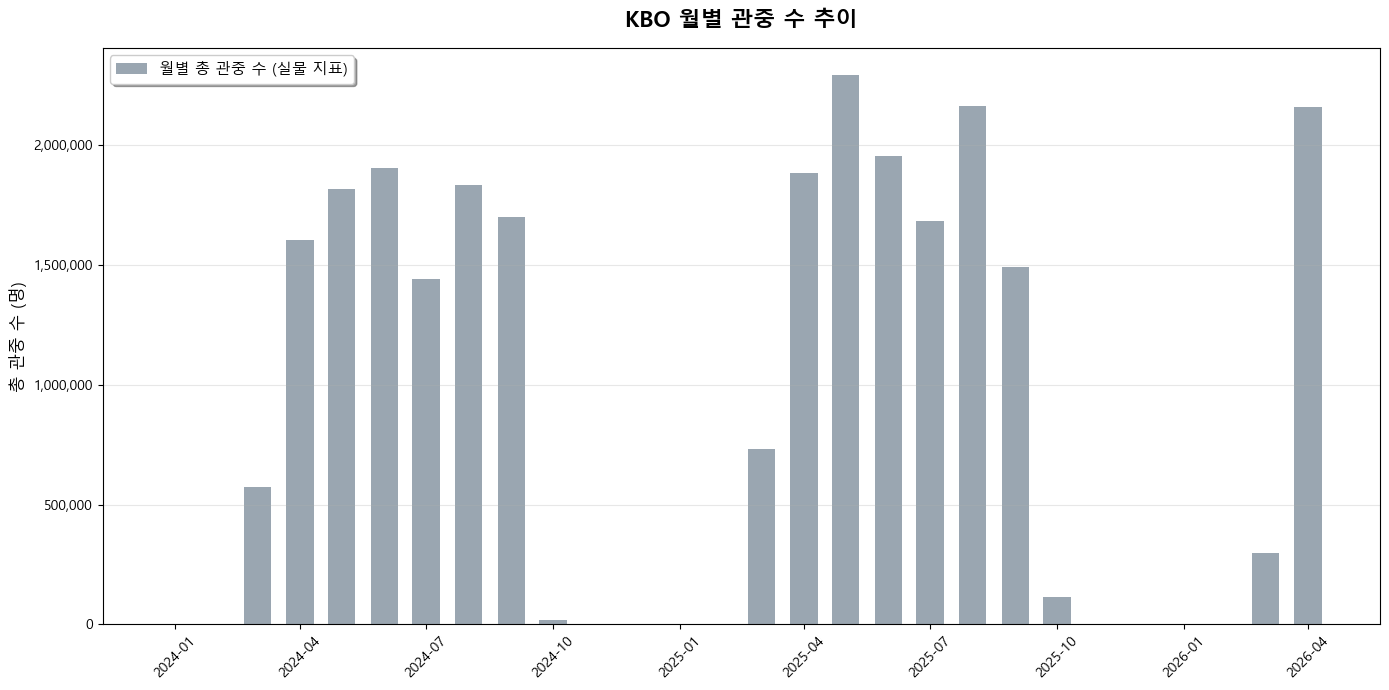

In [464]:
# ==========================================
# 2. 시각화 (관중 수 단독 막대그래프)
# ==========================================
fig, ax = plt.subplots(figsize=(14, 7))

# 막대 그래프: 월별 관중 수 (배경이 아닌 주된 데이터이므로 진하게 표현)
ax.bar(df_final['날짜'], df_final['관중수'], width=20, alpha=0.7, color='slategray', label='월별 총 관중 수 (실물 지표)')

# 차트 꾸미기
# ax.set_xlabel('날짜 (년-월)', fontsize=12)
ax.set_ylabel('총 관중 수 (명)', fontsize=12)
ax.set_title('KBO 월별 관중 수 추이', fontsize=16, fontweight='bold', pad=15)

# Y축 숫자 단위를 보기 쉽게 콤마(,) 형식으로 변경
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# X축 날짜 포맷팅 (YYYY-MM 형태)
date_form = mdates.DateFormatter("%Y-%m")
ax.xaxis.set_major_formatter(date_form)
plt.xticks(rotation=45)

# 범례 및 그리드 추가
ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

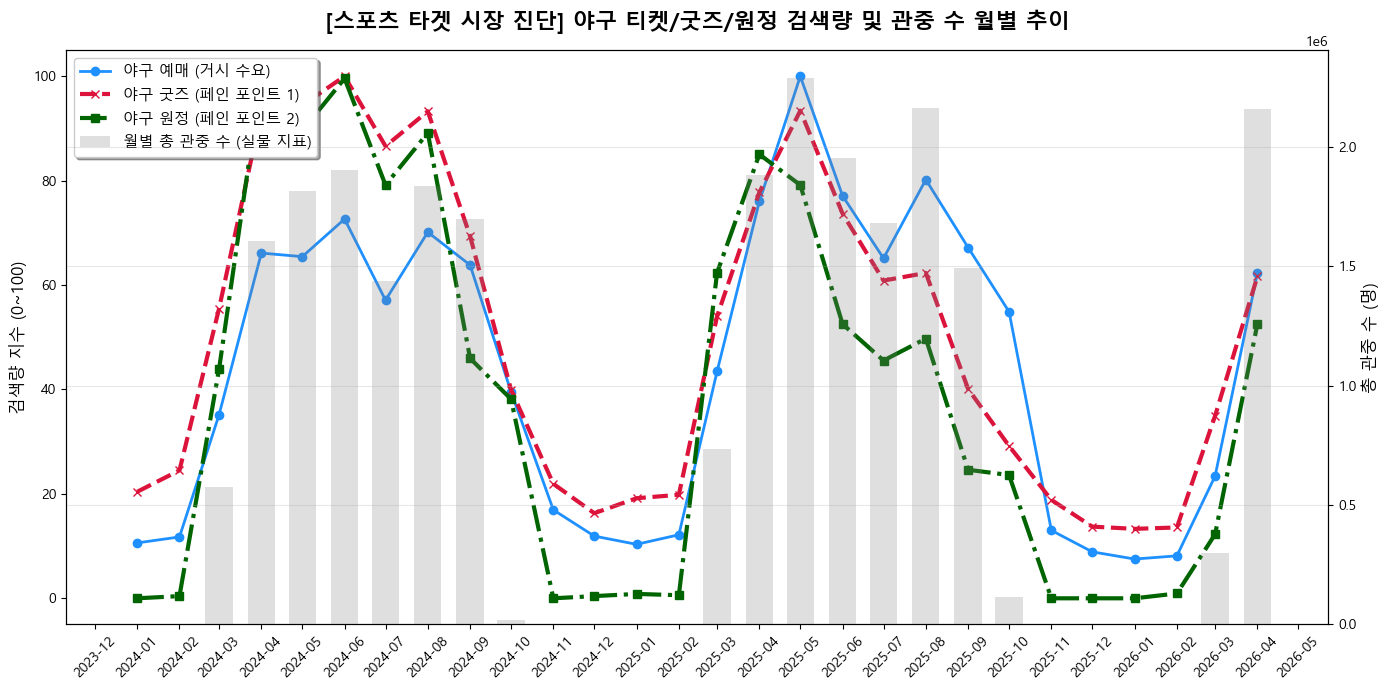

In [402]:
# ========================================
# 시각화
# ========================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# [보조 축 생성] 막대 그래프: 월별 관중 수 (배경에 회색으로 깔기)
ax2 = ax1.twinx()
ax2.bar(df_final['날짜'], df_final['관중수'], width=20, alpha=0.25, color='gray', label='월별 총 관중 수 (실물 지표)')
ax2.set_ylabel('총 관중 수 (명)', fontsize=12)

# [주 축] 선 그래프: 검색량 트렌드 (디커플링 강조)
ax1.plot(df_final['날짜'], df_final['야구 예매'], label='야구 예매 (거시 수요)', color='dodgerblue', linewidth=2, marker='o')
ax1.plot(df_final['날짜'], df_final['야구 굿즈'], label='야구 굿즈 (페인 포인트 1)', color='crimson', linewidth=3, linestyle='--', marker='x')
ax1.plot(df_final['날짜'], df_final['야구 원정'], label='야구 원정 (페인 포인트 2)', color='darkgreen', linewidth=3, linestyle='-.', marker='s')

# 차트 꾸미기
# ax1.set_xlabel('날짜 (년-월)', fontsize=12)
ax1.set_ylabel('검색량 지수 (0~100)', fontsize=12)
ax1.set_title('[스포츠 타겟 시장 진단] 야구 티켓/굿즈/원정 검색량 및 관중 수 월별 추이', fontsize=16, fontweight='bold', pad=15)

# X축 눈금 설정 (1개월 단위)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.get_xticklabels(), rotation=45)

# 범례(Legend) 한 곳으로 통합하기
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, frameon=True, shadow=True)

# 그리드 추가 및 레이아웃 정리
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## [Step 3. 솔루션 및 검증] : "무거운 신상품 대신, 가벼운 '스위칭 플랫폼'으로 록인(Lock-in)"

- 목적: 골든타임 내에 즉시 실행 가능하면서도 리스크를 최소화하는 현실적인 비즈니스 모델을 제시

- 솔루션 제안: 6개월이 걸리는 신규 카드 심사 대신, 자사 앱 내에서 [기존 카드 혜택 스위칭 서비스]를 1~2개월 내에 런칭하여 타겟 고객의 트래픽(MAU)을 흡수

- MVP 방어: 대규모 예산을 투입하기 전, 1주일간 타겟 고객군에게 해당 혜택의 캐시백 마케팅(A/B 테스트)을 선행하여 실제 전환율과 비용 대비 효과(ROI)를 데이터로 먼저 검증하겠다고 선언

In [450]:
# 1. 스포츠 관련 키워드가 원본 카테고리에 포함된 카드만 필터링
sports_keywords = ['경기관람', '레저/스포츠']
# 람다 함수를 통해 카테고리 텍스트 안에 스포츠 키워드가 하나라도 있는지 확인
df_sports = df[df['카테고리'].apply(
    lambda x: any(keyword in str(x) for keyword in sports_keywords))].copy()

In [455]:
len(df_sports)

453

In [451]:
df_sports['전월실적'] = pd.to_numeric(df_sports['전월실적'], errors='coerce').fillna(0)
df_sports['연회비'] = pd.to_numeric(df_sports['연회비'], errors='coerce').fillna(0)

In [452]:
# df_sports.to_csv('data/sports_card.csv', index=True, encoding='utf-8-sig')

In [458]:
df_alive = df_sports.loc[df_sports.loc[:, '발급가능여부'] == 'O']
df_alive['주요혜택'] = df_alive['주요혜택'].astype(str)
print(df_alive.shape)
df_alive.head()

(97, 10)


,카드명,카드사,카드타입,출시일,연회비,전월실적,카테고리,주요혜택,발급가능여부,소비_영역_대분류
카드번호,,,,,,,,,,
125,E1 LPG KB국민카드,KB국민카드,CRD,NaN,20000,500000,"[주유, 레저/스포츠, 쇼핑, 푸드, OTT/영화/문화, 교통]","E1 LPG충전소 100원/L 할인, 인터넷 쇼핑몰 10% 할인, CGV 10% 할인",O,"[쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화]"
161,NC다이노스카드,NH농협카드,CRD,NaN,8000,300000,"[경기관람, 온라인쇼핑, 영화, 카페, 테마파크, 통신]","NC다이노스 2,000원 입장료할인, 온라인쇼핑 10% 할인, CGV,롯데시네마 3...",O,"[쇼핑/유통, 생활/고정비, 외식/푸드, 여가/문화]"
207,경차 smart 롯데카드,롯데카드,CRD,NaN,0,300000,"[주유소, 대중교통, 쇼핑, 정비, 헤어, 테마파크, 경기관람, 영화, 패밀리레스토랑]","경차 유류세 환급, 주유소 리터당 80원 할인, 스피드메이트 엔진오일 할인",O,"[쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화, 생활/고정비]"
263,참! 좋은 kt wiz 카드(신용),IBK기업은행,CRD,NaN,2000,0,"[모든가맹점, 주유소, 대형마트, 영화, 소셜커머스, 카페, 패밀리레스토랑, 테마파...","국내가맹점 0.2~0.4% 적립, kt wiz 입장권/야구용품 할인, 마트/외식/쇼...",O,"[쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화, 광범위]"
325,그랑블루 체크카드,우리카드,CHK,NaN,95000,300000,"[바우처, 모든가맹점, 공항라운지/PP, 여행/숙박, 푸드, 영화, 레저/스포츠, ...","모아포인트 0.3~1.0% 적립, 기프트바우처 연1회 제공, 공항라운지 무료 이용",O,"[교통/모빌리티, 외식/푸드, 여가/문화, 여행/항공, 광범위]"


In [459]:
stats = df_alive.groupby('카드타입')[['연회비', '전월실적']].agg(['mean', 'median', 'count'])
# 보기 편하게 컬럼명 다듬기
stats.columns = ['연회비_평균', '연회비_중앙값', '카드_수', '전월실적_평균', '전월실적_중앙값', '카드_수(중복)']
stats = stats.drop(columns=['카드_수(중복)'])

print("■ 발급 가능 스포츠 카드: 신용카드(CRD) vs 체크카드(CHK) 통계")
print(stats.map(lambda x: f"{x:,.0f}"))

■ 발급 가능 스포츠 카드: 신용카드(CRD) vs 체크카드(CHK) 통계
      연회비_평균 연회비_중앙값 카드_수  전월실적_평균 전월실적_중앙값
카드타입                                       
CHK    2,000       0   49  183,673  200,000
CRD   32,667  12,000   48  252,083  300,000


In [447]:
# 2. 혜택 키워드 카운팅 (티켓 vs 사각지대)
keywords = {
    '티켓/예매 (기존 혜택)': ['티켓', '예매', '관람', '입장료', '입장권', '프로스포츠', '프로야구', '홈경기', '두산베어스'],
    '유니폼/굿즈 (사각지대)': ['유니폼', '굿즈', '스토어', '어센틱', '레플리카', '야구용품', '야구장 편의시설'],
    '원정/교통 (사각지대)': ['원정', 'KTX', 'SRT', '고속버스', '대중교통', '호텔', '숙박']
}

benefit_counts = {'카테고리': [], '카드 수': []}
for cat, kw_list in keywords.items():
    # 해당 카테고리의 키워드가 하나라도 포함된 카드 수 계산
    count = df_alive['주요혜택'].apply(lambda x: any(kw in x for kw in kw_list)).sum()
    benefit_counts['카테고리'].append(cat)
    benefit_counts['카드 수'].append(count)

df_counts = pd.DataFrame(benefit_counts)

In [448]:
df_counts

,카테고리,카드 수
0,티켓/예매 (기존 혜택),18
1,유니폼/굿즈 (사각지대),7
2,원정/교통 (사각지대),4


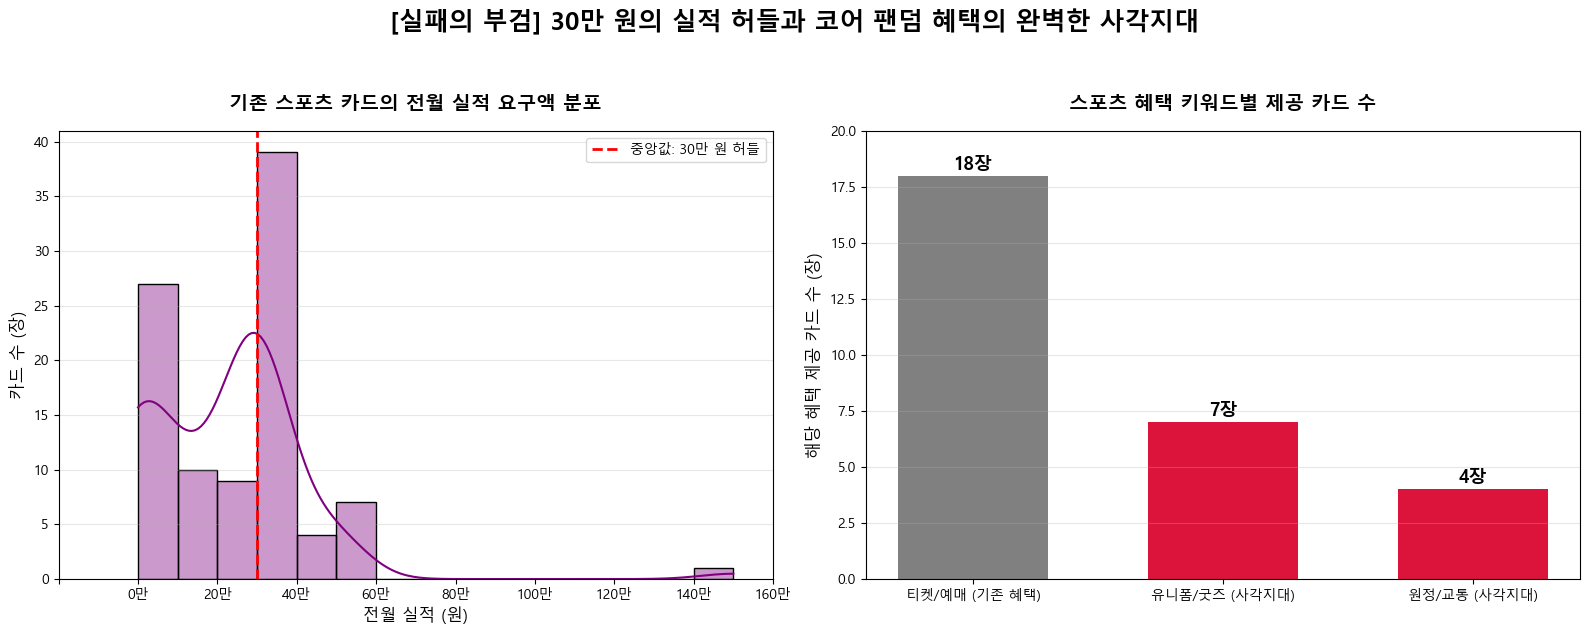

In [449]:
# ==========================================
# 3. 1x2 서브플롯 시각화
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# [왼쪽 차트] 스포츠 카드 전월 실적 분포 (KDE + 히스토그램)
sns.histplot(data=df_alive, x='전월실적', bins=15, kde=True, color='purple', ax=ax1, alpha=0.4)
ax1.set_title('기존 스포츠 카드의 전월 실적 요구액 분포', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('전월 실적 (원)', fontsize=12)
ax1.set_ylabel('카드 수 (장)', fontsize=12)

# X축 10만 원 단위로 깔끔하게 변경
ticks = ax1.get_xticks()
ax1.set_xticks(ticks)
ax1.set_xticklabels([f'{int(x/10000)}만' if x >= 0 else '' for x in ticks])

# 30만 원 구간 강조 수직선
ax1.axvline(300000, color='red', linestyle='--', linewidth=2, label='중앙값: 30만 원 허들')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# [오른쪽 차트] 혜택 사각지대 바 차트
colors = ['gray', 'crimson', 'crimson']
bars = ax2.bar(df_counts['카테고리'], df_counts['카드 수'], color=colors, width=0.6)
ax2.set_title('스포츠 혜택 키워드별 제공 카드 수', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('해당 혜택 제공 카드 수 (장)', fontsize=12)

# 바 위에 숫자 텍스트 달기
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{int(height)}장', 
             ha='center', va='bottom', fontsize=13, fontweight='bold', color='black')

ax2.set_ylim(0, max(df_counts['카드 수']) + 2) # Y축 여백 주기
ax2.grid(axis='y', alpha=0.3)

# 전체 타이틀 및 레이아웃 정리
plt.suptitle('[실패의 부검] 30만 원의 실적 허들과 코어 팬덤 혜택의 완벽한 사각지대', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [363]:
df_sports_end = df_sports.loc[df_sports.loc[:, '발급가능여부'] == 'X']
print(df_sports_end.shape)
df_sports_end.head()

(373, 10)


,카드명,카드사,카드타입,출시일,연회비,전월실적,카테고리,주요혜택,발급가능여부,소비_영역_대분류
카드번호,,,,,,,,,,
2,신한카드 Love,신한카드,CRD,NaN,8000,200000,"[백화점, 패밀리레스토랑, 주유소, 영화, 적립, 테마파크, 경기관람]","백화점/할인점 5% 할인, 스타벅스 20% 할인, GS칼텍스 60원/L 할인",X,"[쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화]"
3,신한카드 Lady,신한카드,CRD,NaN,5000,300000,"[쇼핑, 푸드, 영화, 주유소, 교육/육아, 테마파크, 통신, 경기관람]","3대백화점 5% 할인, 패밀리레스토랑 20% 할인, 놀이공원 30~50% 할인",X,"[쇼핑/유통, 교통/모빌리티, 외식/푸드, 여가/문화, 생활/고정비]"
4,SK에너지 신한카드The you,신한카드,CRD,NaN,7000,300000,"[주유소, 대중교통, 무이자할부, 테마파크, 영화, 헤어, 경기관람, 여행사]","SK주유소 100원/L 할인, 지하철,버스,택시 3~7% 할인, 놀이공원 30~50...",X,"[여행/항공, 생활/고정비, 교통/모빌리티, 여가/문화]"
50,아시아나 삼성지엔미플래티늄카드,삼성카드,CRD,NaN,0,300000,"[아시아나항공, 주유소, 패밀리레스토랑, 카페, 영화, 테마파크, 정비, 무이자할부...","1,000원당 1~5마일 적립, S-OIL주유소 40/L 적립, CGV 3,000원 할인",X,"[여행/항공, 교통/모빌리티, 외식/푸드, 여가/문화]"
78,블루다이아몬드Ⅱ 카드,우리카드,CRD,NaN,95000,300000,"[모든가맹점, 항공마일리지, 바우처, 여행/숙박, 생활, 골프]","포인트형 0.5~1.5% 적립, 대한항공형 1.500원/1마일 적립, 아시아나항공형...",X,"[여행/항공, 광범위, 생활/고정비, 여가/문화]"
